# Azobenzene S0/S1 energy surfaces

Plot the raw reference ground-state (S0) and first-excited-state (S1) energies over the C–N=N–C dihedral and N=N bond-length coordinates.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
from ase.io import read

# Support launching Jupyter from either notebooks/ or the repository root.
XYZ_NAME = Path("data/azoflip_data/XYZ/azobenzene_grid_static_CASSCF_collision_filtered.xyz")
XYZ_PATH = next((candidate for candidate in (Path.cwd() / XYZ_NAME, Path.cwd().parent / XYZ_NAME) if candidate.exists()), None)
if XYZ_PATH is None:
    raise FileNotFoundError(f"Could not find {XYZ_NAME} from {Path.cwd()}")
TEST_XYZ_NAME = Path("data/azoflip_data/XYZ/1367_ground_first_forces-and-energies.xyz")
TEST_XYZ_PATH = next((candidate for candidate in (Path.cwd() / TEST_XYZ_NAME, Path.cwd().parent / TEST_XYZ_NAME) if candidate.exists()), None)
if TEST_XYZ_PATH is None:
    raise FileNotFoundError(f"Could not find {TEST_XYZ_NAME} from {Path.cwd()}")
DIHEDRAL_ATOMS = (3, 4, 5, 6)  # C–N=N–C; zero-based ASE atom indices
NN_ATOMS = (4, 5)
NNC_LEFT_ATOMS = (3, 4, 5)
NNC_RIGHT_ATOMS = (4, 5, 6)
BENZENE_RING_1_ATOMS = (0, 1, 2, 3, 12, 13)
BENZENE_RING_2_ATOMS = (6, 7, 8, 9, 10, 11)

def benzene_ring_normal_angle(atoms, ring_1=BENZENE_RING_1_ATOMS, ring_2=BENZENE_RING_2_ATOMS):
    """Return the unsigned angle (0–90°) between two best-fit benzene-ring normals."""
    def plane_normal(atom_indices):
        positions = atoms.get_positions()[list(atom_indices)]
        _, singular_values, right_vectors = np.linalg.svd(positions - positions.mean(axis=0))
        if singular_values[1] < 1e-12:
            raise ValueError("Cannot determine a ring normal from collinear atom positions.")
        return right_vectors[-1]

    normal_1, normal_2 = plane_normal(ring_1), plane_normal(ring_2)
    cosine = np.clip(abs(np.dot(normal_1, normal_2)), -1.0, 1.0)
    return float(np.degrees(np.arccos(cosine)))

frames = read(XYZ_PATH, index=":")
test_frames = read(TEST_XYZ_PATH, index=":")
raw_dihedral_deg = np.asarray([atoms.get_dihedral(*DIHEDRAL_ATOMS) for atoms in frames])
centered_dihedral_deg = (raw_dihedral_deg + 180.0) % 360.0 - 180.0
dihedral_deg = np.abs(180.0 - np.abs(centered_dihedral_deg))  # cis=0°, trans=180°
nn_bond_angstrom = np.asarray([atoms.get_distance(*NN_ATOMS) for atoms in frames])
nnc_left_angle_deg = np.asarray([atoms.get_angle(*NNC_LEFT_ATOMS) for atoms in frames])
nnc_right_angle_deg = np.asarray([atoms.get_angle(*NNC_RIGHT_ATOMS) for atoms in frames])
if not np.allclose(nnc_left_angle_deg, nnc_right_angle_deg, atol=1e-5):
    raise ValueError("The grid does not have symmetric left/right NNC angles.")
nnc_angle_deg = 0.5 * (nnc_left_angle_deg + nnc_right_angle_deg)

nn_values = np.round(np.arange(1.20, 1.50 + 0.001, 0.05), 2)
nnc_values = np.arange(110.0, 140.0 + 0.1, 5.0)
ring_twist_values = 0.1 + np.arange(11, dtype=float) * 17.98
dihedral_values = 0.1 + np.arange(21, dtype=float) * 8.99
grid_shape = (len(nn_values), len(nnc_values), len(ring_twist_values), len(dihedral_values))

'''
if len(frames) != np.prod(grid_shape):
    raise ValueError(f"Expected {np.prod(grid_shape):,} grid frames, found {len(frames):,}.")
grid_indices = np.column_stack(np.unravel_index(np.arange(len(frames)), grid_shape))
# The static CASSCF export stores the final (CNNC) axis in descending order.
stored_dihedral_values = dihedral_values[::-1]
ring_twist_angle_deg = ring_twist_values[grid_indices[:, 2]]
if not (
    np.allclose(nn_bond_angstrom, nn_values[grid_indices[:, 0]], atol=1e-5)
    and np.allclose(nnc_angle_deg, nnc_values[grid_indices[:, 1]], atol=1e-5)
    and np.allclose(dihedral_deg, stored_dihedral_values[grid_indices[:, 3]], atol=1e-5)
):
    raise ValueError("CASSCF frame order or geometric coordinates do not match the generated grid.")
'''


test_raw_dihedral_deg = np.asarray([atoms.get_dihedral(*DIHEDRAL_ATOMS) for atoms in test_frames])
test_dihedral_deg = np.abs(180.0 - np.abs((test_raw_dihedral_deg + 180.0) % 360.0 - 180.0))
test_nn_bond_angstrom = np.asarray([atoms.get_distance(*NN_ATOMS) for atoms in test_frames])
energies_ev = np.vstack([np.asarray(atoms.info["REF_energy"], dtype=float).ravel()[:2] for atoms in frames])

if energies_ev.shape[1] != 2 or not np.isfinite(energies_ev).all():
    raise ValueError(f"Expected two finite CASSCF energy states, got shape {energies_ev.shape}.")
if not (-15486.0 <= energies_ev.min() and energies_ev.max() <= -13974.0):
    raise ValueError("CASSCF energies are outside the expected eV range.")

print(f"Loaded {len(frames)} geometries")
print(f"Loaded {len(test_frames)} test-set geometries")
print(f"Chemical CNNC dihedral range: {dihedral_deg.min():.1f}–{dihedral_deg.max():.1f}°")
print(f"N=N range: {nn_bond_angstrom.min():.3f}–{nn_bond_angstrom.max():.3f} Å")

Loaded 10477 geometries
Loaded 461 test-set geometries
Chemical CNNC dihedral range: 0.1–179.9°
N=N range: 1.200–1.500 Å


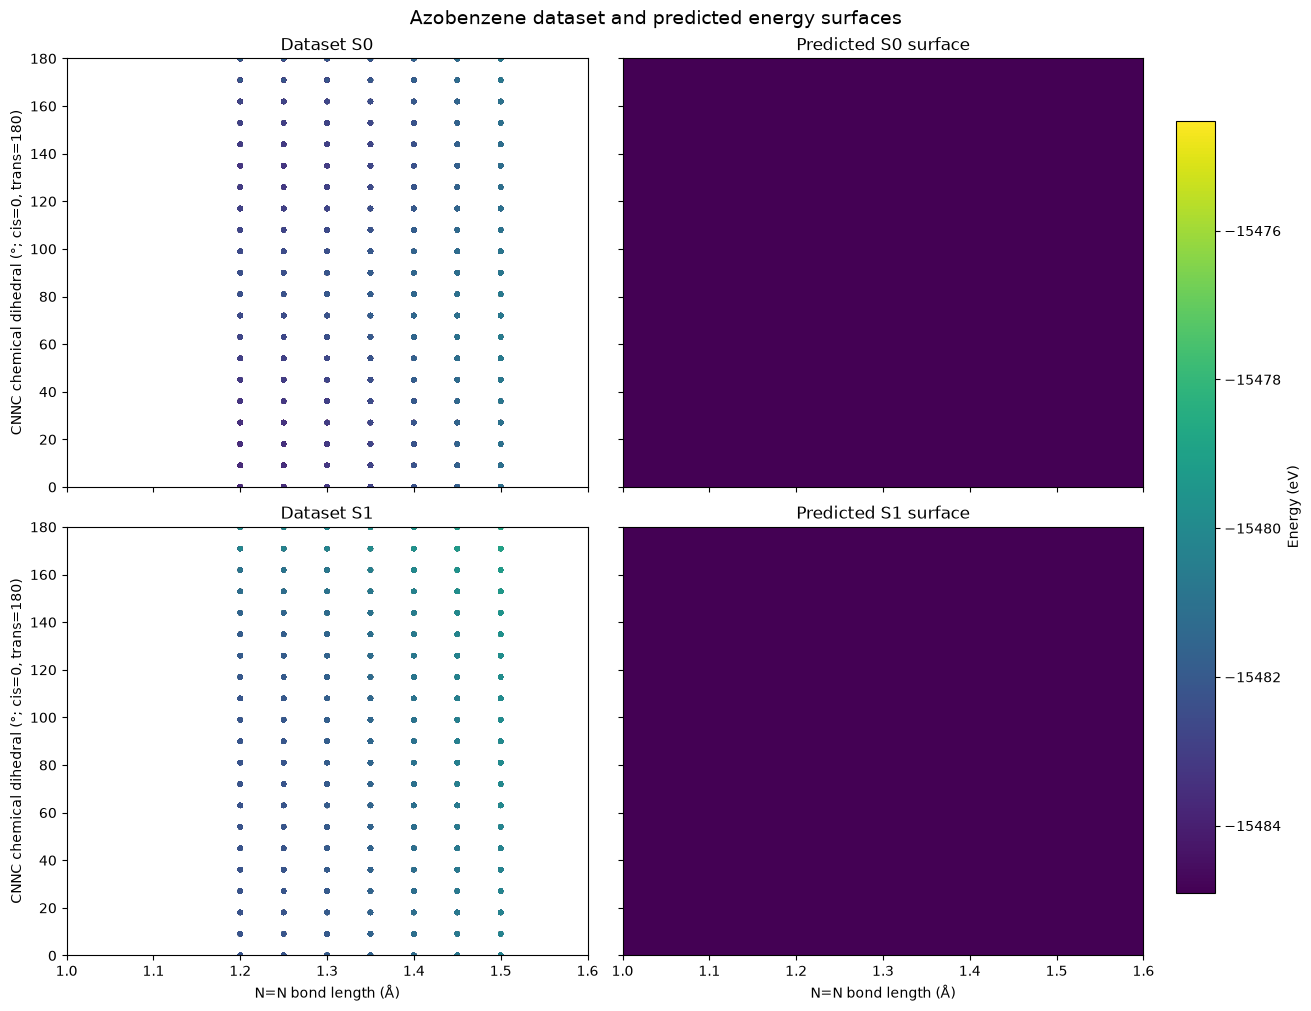

In [4]:
# Compare dataset points with the predicted static-grid energy surfaces.
# All panels use the fixed shared energy scale requested for direct comparison.
%matplotlib inline

HARTREE_TO_EV = 27.211386245988  # Legacy predicted-grid energies are stored in Hartree.
DISPLAY_VMIN, DISPLAY_VMAX = np.percentile(energies_ev, (1.0, 99.0))
ENERGY_AXIS_LIMITS = (float(energies_ev.min()), float(energies_ev.max()))
energy_norm = Normalize(vmin=DISPLAY_VMIN, vmax=DISPLAY_VMAX)

PREDICTED_GRID_NAME = Path("data/azoflip_data/XYZ/azobenzene_variable_rotation_grid_static.xyz")
PREDICTED_GRID_PATH = next(
    (candidate for candidate in (Path.cwd() / PREDICTED_GRID_NAME, Path.cwd().parent / PREDICTED_GRID_NAME)
     if candidate.exists()),
    None,
)
if PREDICTED_GRID_PATH is None:
    raise FileNotFoundError(f"Could not find {PREDICTED_GRID_NAME} from {Path.cwd()}")

predicted_frames = read(PREDICTED_GRID_PATH, index=":")
predicted_dihedrals = 180.0 - np.asarray([frame.info["cnnc_dihedral_deg"] for frame in predicted_frames], dtype=float)
predicted_nn_distances = np.asarray(
    [frame.info["nn_distance_angstrom"] for frame in predicted_frames], dtype=float
)
predicted_energies_ev = np.vstack([
    np.asarray(frame.info["REF_energy"], dtype=float).reshape(-1)[:2]
    for frame in predicted_frames
]) * HARTREE_TO_EV

predicted_dihedral_values = np.unique(predicted_dihedrals)
predicted_nn_values = np.unique(predicted_nn_distances)
if len(predicted_frames) != len(predicted_dihedral_values) * len(predicted_nn_values):
    raise ValueError("Predicted grid is incomplete or contains duplicate coordinate pairs.")

predicted_energy_grid_ev = np.full(
    (2, len(predicted_nn_values), len(predicted_dihedral_values)), np.nan
)
dihedral_index = {value: index for index, value in enumerate(predicted_dihedral_values)}
nn_index = {value: index for index, value in enumerate(predicted_nn_values)}
for dihedral, bond_length, state_energies in zip(
    predicted_dihedrals, predicted_nn_distances, predicted_energies_ev
):
    predicted_energy_grid_ev[:, nn_index[bond_length], dihedral_index[dihedral]] = state_energies
if np.isnan(predicted_energy_grid_ev).any():
    raise ValueError("Could not populate every S0/S1 predicted-grid point.")

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True, constrained_layout=True)
for state in range(2):
    dataset_axis, predicted_axis = axes[state]
    dataset_axis.scatter(
        nn_bond_angstrom, dihedral_deg, c=energies_ev[:, state], cmap="viridis", norm=energy_norm,
        s=14, alpha=0.8, linewidths=0,
    )
    predicted_axis.imshow(
        predicted_energy_grid_ev[state].T, origin="lower", aspect="auto",
        extent=(predicted_nn_values[0], predicted_nn_values[-1], 0, 180),
        cmap="viridis", norm=energy_norm, interpolation="nearest",
    )
    dataset_axis.set(title=f"Dataset S{state}")
    predicted_axis.set(title=f"Predicted S{state} surface")

for axis in axes[-1]:
    axis.set(xlabel="N=N bond length (Å)", xlim=(1.0, 1.6))
for axis in axes[:, 0]:
    axis.set(ylabel="CNNC chemical dihedral (°; cis=0, trans=180)", ylim=(0, 180))

colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=energy_norm, cmap="viridis"), ax=axes, shrink=0.86, pad=0.02
)
colorbar.set_label("Energy (eV)")
fig.suptitle("Azobenzene dataset and predicted energy surfaces", fontsize=14)
plt.show()


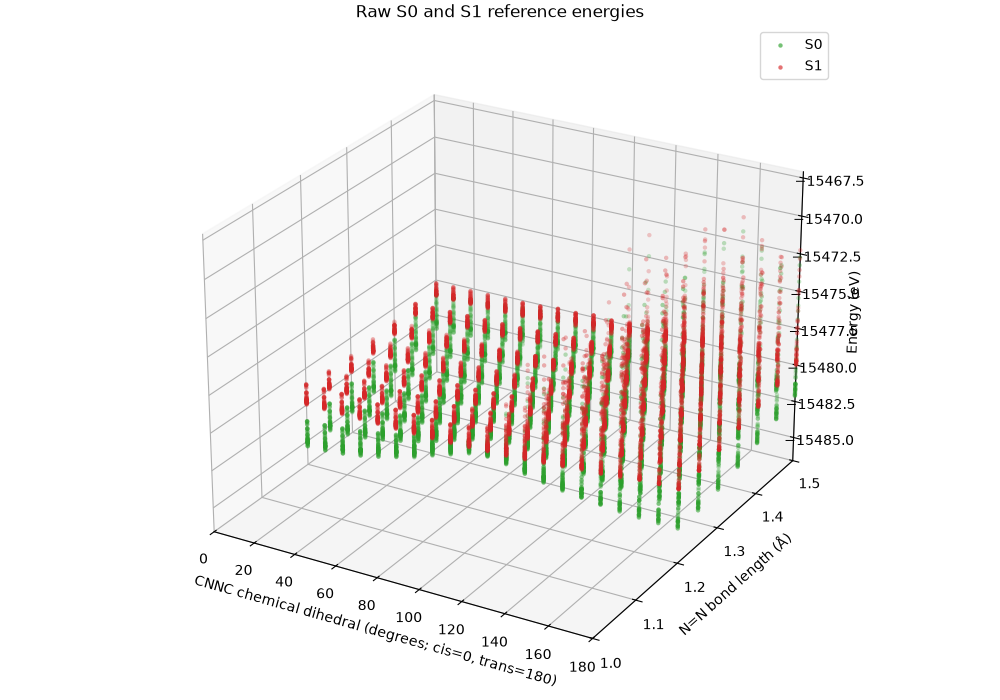

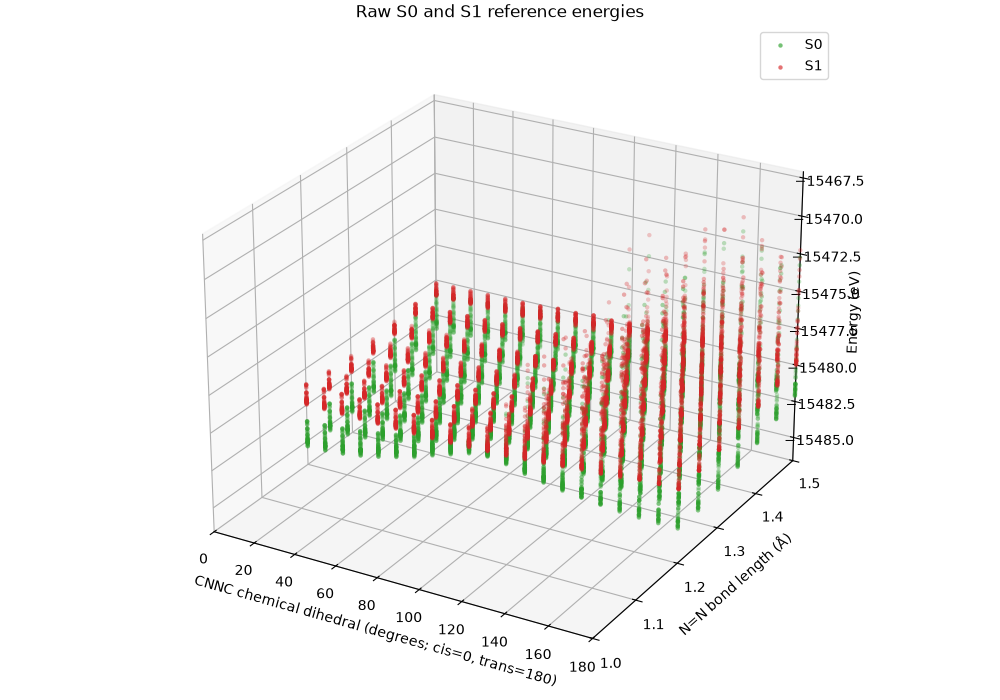

In [5]:
# 3D view of the calculated points, using the raw reference energies.
%matplotlib widget

fig = plt.figure(figsize=(10, 7), constrained_layout=True)
ax = fig.add_subplot(projection="3d")

ax.scatter(
    dihedral_deg, nn_bond_angstrom, energies_ev[:, 0],
    color="tab:green", s=10, alpha=0.65, linewidths=0, label="S0",
)
ax.scatter(
    dihedral_deg, nn_bond_angstrom, energies_ev[:, 1],
    color="tab:red", s=10, alpha=0.65, linewidths=0, label="S1",
)

ax.set_xlabel("CNNC chemical dihedral (degrees; cis=0, trans=180)")
ax.set_ylabel("N=N bond length (Å)")
ax.set_zlabel("Energy (eV)")
ax.set_xlim(0, 180)
ax.set_ylim(1.0, 1.5)
#ax.set_zlim(-572.4, -572.1)
ax.view_init(elev=25, azim=-60)
ax.legend()
ax.set_title("Raw S0 and S1 reference energies")
plt.show()

fig = plt.figure(figsize=(10, 7), constrained_layout=True)
ax = fig.add_subplot(projection="3d")

ax.scatter(
    dihedral_deg, nn_bond_angstrom, energies_ev[:, 0],
    color="tab:green", s=10, alpha=0.65, linewidths=0, label="S0",
)
ax.scatter(
    dihedral_deg, nn_bond_angstrom, energies_ev[:, 1],
    color="tab:red", s=10, alpha=0.65, linewidths=0, label="S1",
)

ax.set_xlabel("CNNC chemical dihedral (degrees; cis=0, trans=180)")
ax.set_ylabel("N=N bond length (Å)")
ax.set_zlabel("Energy (eV)")
ax.set_xlim(0, 180)
ax.set_ylim(1.0, 1.5)
#ax.set_zlim(-572.4, -572.1)
ax.view_init(elev=25, azim=-60)
ax.legend()
ax.set_title("Raw S0 and S1 reference energies")
plt.show()

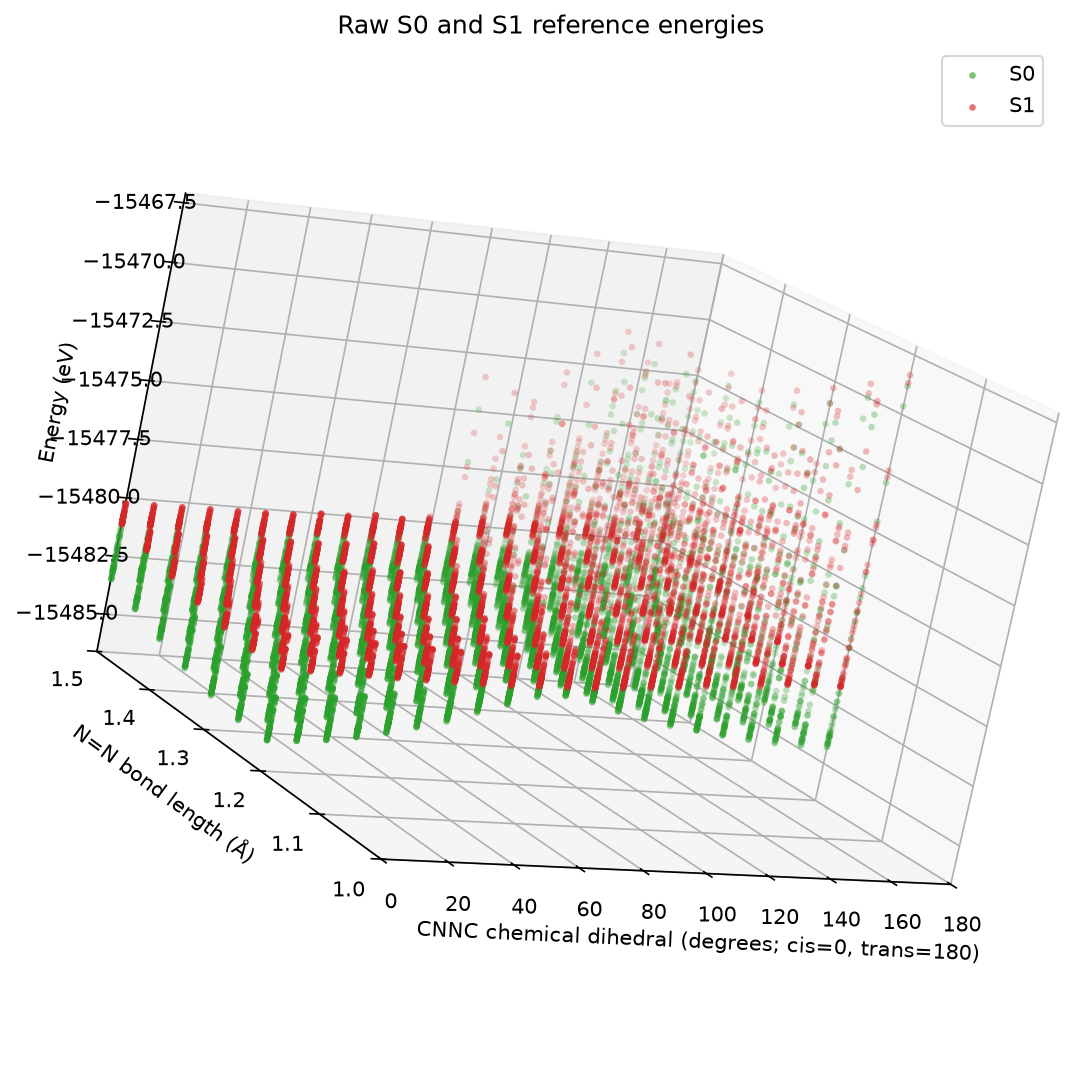

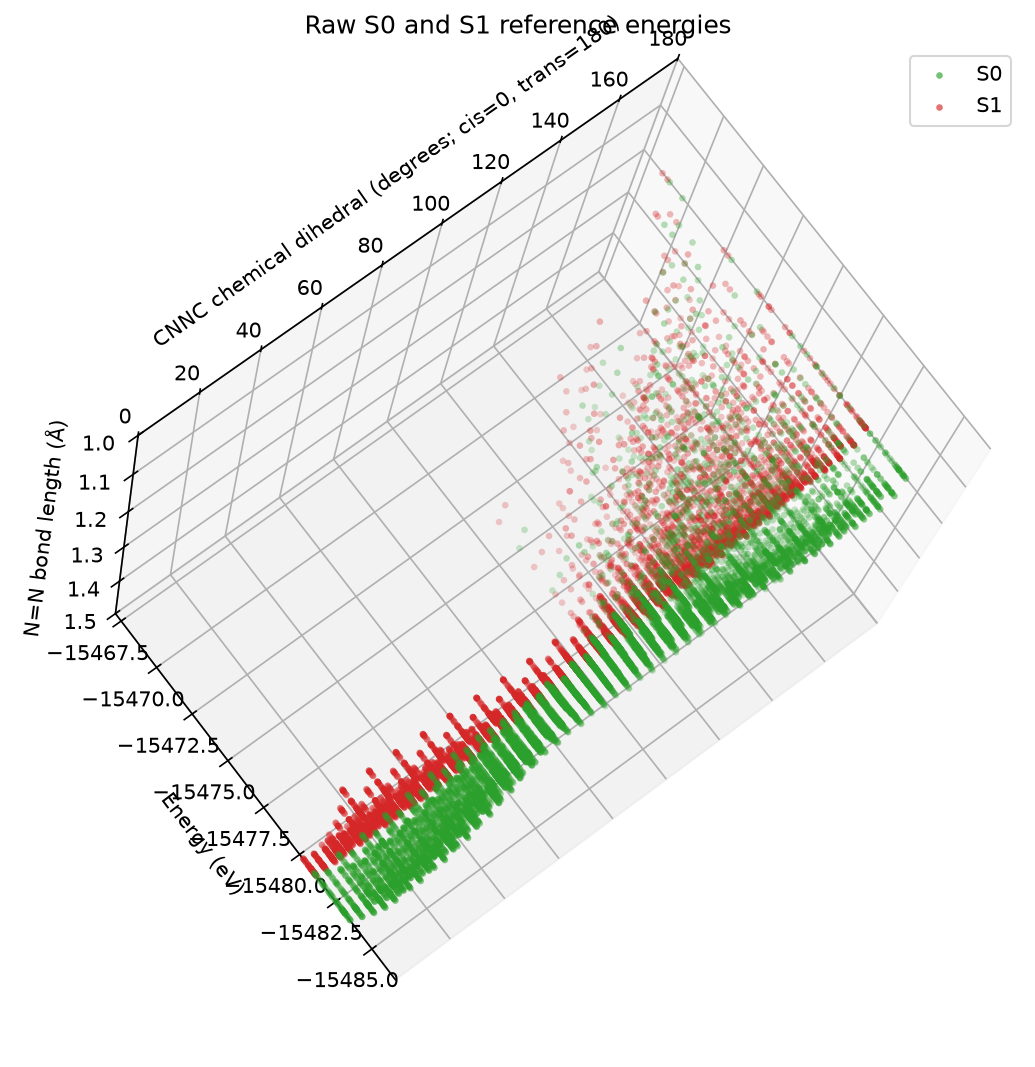

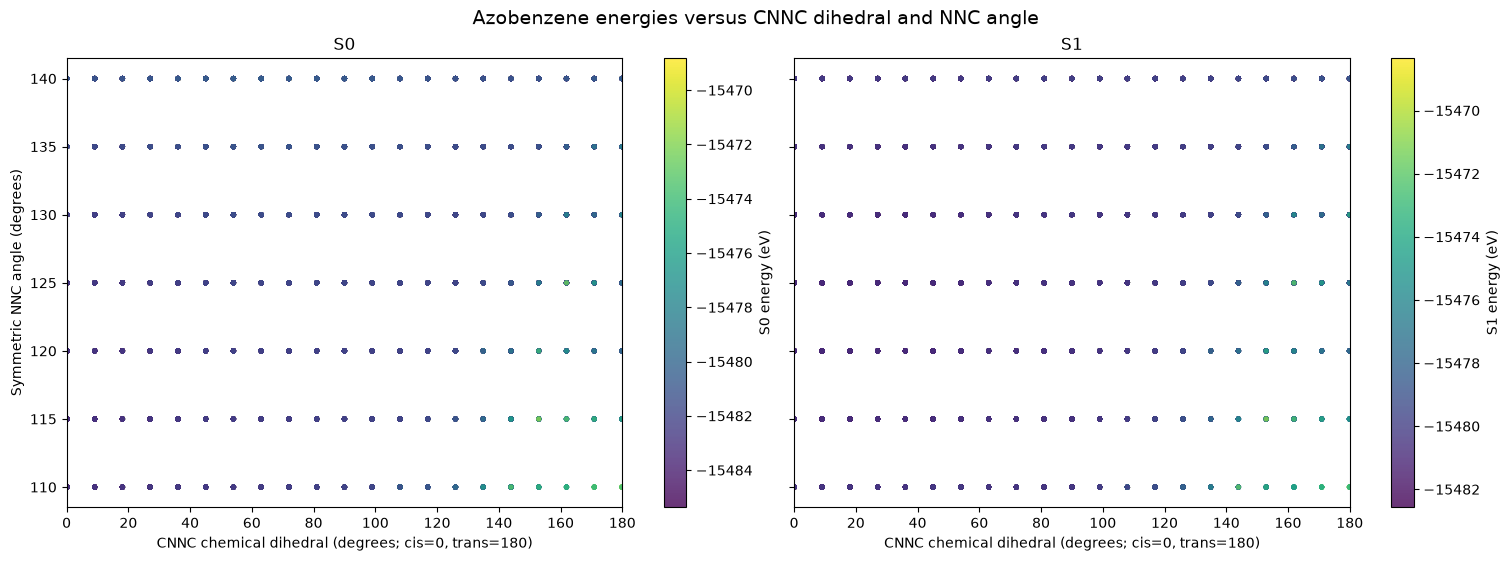

In [6]:
# Scatter S0 and S1 energies against the CNNC dihedral and N=N--C angle.
# The grid NNC coordinate is the symmetric mean of the left and right NNC angles.
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True, sharey=True, constrained_layout=True)
for state, axis in enumerate(axes):
    scatter = axis.scatter(
        dihedral_deg, nnc_angle_deg, c=energies_ev[:, state],
        cmap="viridis", s=14, alpha=0.8, linewidths=0,
    )
    axis.set(
        title=f"S{state}",
        xlabel="CNNC chemical dihedral (degrees; cis=0, trans=180)",
        xlim=(0, 180),
    )
    fig.colorbar(scatter, ax=axis, label=f"S{state} energy (eV)")
axes[0].set_ylabel("Symmetric NNC angle (degrees)")
fig.suptitle("Azobenzene energies versus CNNC dihedral and NNC angle", fontsize=14)
plt.show()


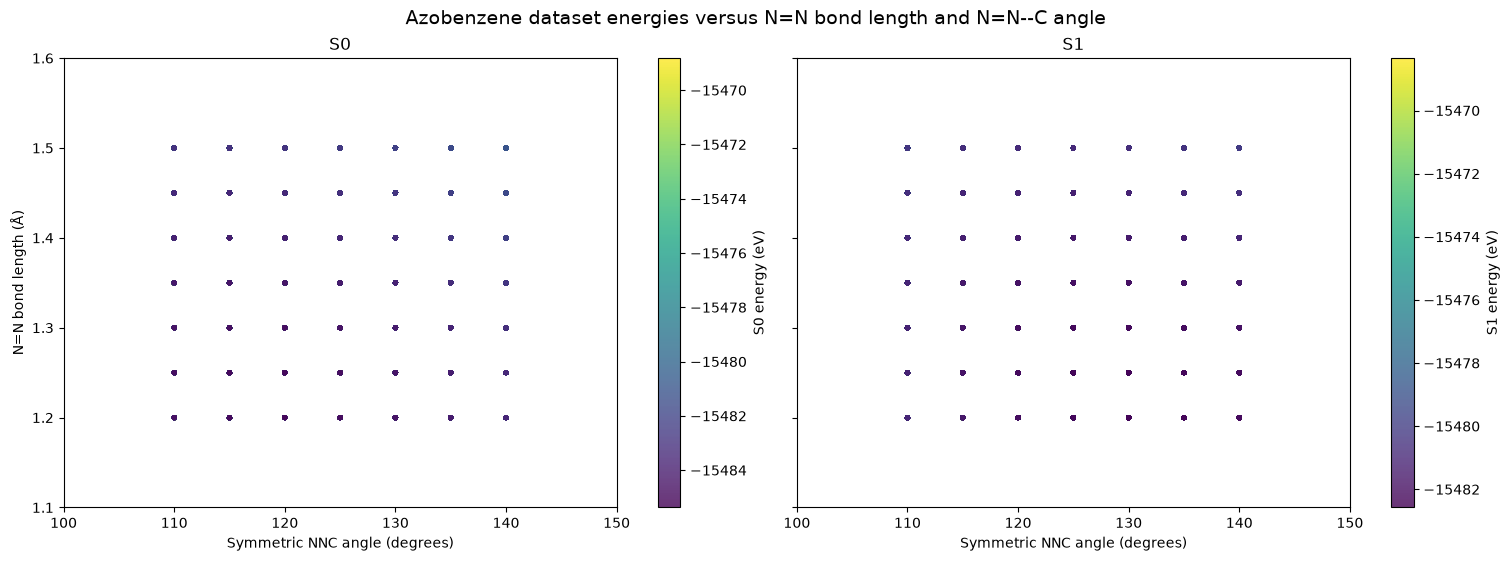

In [7]:
# Scatter S0 and S1 dataset energies against N=N--C angle and N=N bond length.
# nnc_angle_deg is the symmetric NNC coordinate defined in the loading cell.

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True, sharey=True, constrained_layout=True)
for state, axis in enumerate(axes):
    scatter = axis.scatter(
        nnc_angle_deg, nn_bond_angstrom, c=energies_ev[:, state],
        cmap="viridis", s=14, alpha=0.8, linewidths=0,
    )
    axis.set(title=f"S{state}", xlabel="Symmetric NNC angle (degrees)", xlim=(100, 150), ylim=(1.1, 1.6))
    fig.colorbar(scatter, ax=axis, label=f"S{state} energy (eV)")

axes[0].set_ylabel("N=N bond length (Å)")
fig.suptitle("Azobenzene dataset energies versus N=N bond length and N=N--C angle", fontsize=14)
plt.show()


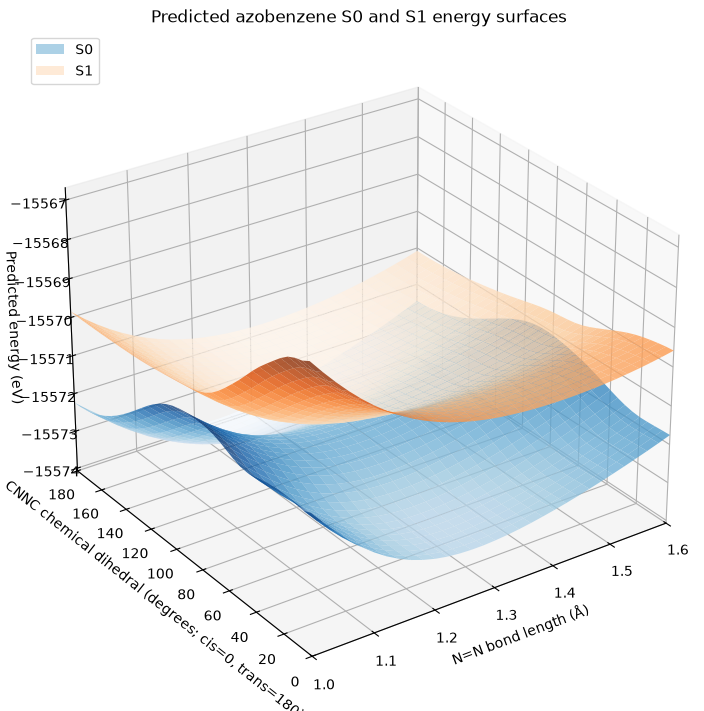

In [8]:
# 3D view of the predicted static-grid S0 and S1 energy surfaces.
%matplotlib inline

predicted_dihedral_mesh, predicted_nn_mesh = np.meshgrid(
    predicted_dihedral_values, predicted_nn_values
)
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
axis = fig.add_subplot(projection="3d")
s0_surface = axis.plot_surface(
    predicted_nn_mesh, predicted_dihedral_mesh, predicted_energy_grid_ev[0],
    cmap="Blues", linewidth=0, antialiased=True, alpha=0.78,
)
s1_surface = axis.plot_surface(
    predicted_nn_mesh, predicted_dihedral_mesh, predicted_energy_grid_ev[1],
    cmap="Oranges", linewidth=0, antialiased=True, alpha=0.78,
)
axis.set(
    title="Predicted azobenzene S0 and S1 energy surfaces",
    xlabel="N=N bond length (Å)", xlim=(1.0, 1.6),
    ylabel="CNNC chemical dihedral (degrees; cis=0, trans=180)", ylim=(0, 180),
    zlabel="Predicted energy (eV)",
)
axis.view_init(elev=28, azim=-125)
axis.legend([s0_surface, s1_surface], ["S0", "S1"], loc="upper left")
plt.show()


## Full-dataset pairwise correlation analysis

The CNNC dihedral is shown in its raw 0–360° range. Structures are limited to N=N bond lengths from 1.1 to 1.6 Å. Pearson coefficients summarize linear associations; Spearman coefficients summarize monotonic associations.

,count,mean,std,min,25%,50%,75%,max
S0 energy (eV),10477.0,-15482.518510,1.645176,-15485.374985,-15483.409966,-15482.690574,-15482.023329,-15468.818129
S1 energy (eV),10477.0,-15480.873121,1.593151,-15482.576830,-15481.852569,-15481.266442,-15480.517600,-15468.339435
Ring twist angle (°),10477.0,89.502319,56.941266,0.100000,36.060000,90.000000,143.940000,179.900000
N=N bond length (Å),10477.0,1.350706,0.100036,1.200000,1.250000,1.350000,1.450000,1.500000
CNNC chemical dihedral (°),10477.0,84.260369,52.332502,0.099999,36.060000,81.010000,125.960000,179.900001
Symmetric NNC angle (°),10477.0,125.733989,9.893745,110.000000,115.000000,125.000000,135.000000,140.000000


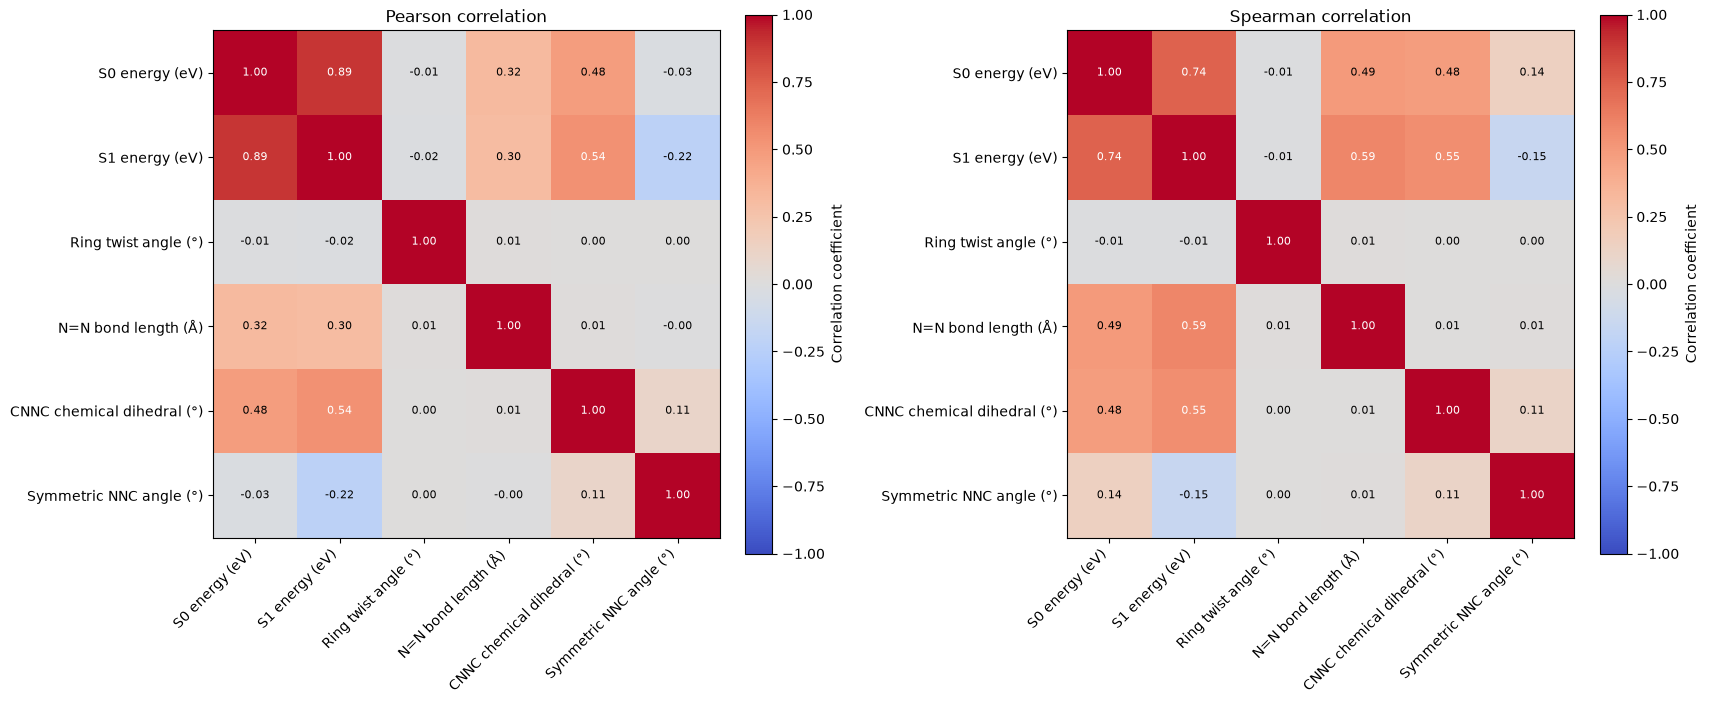

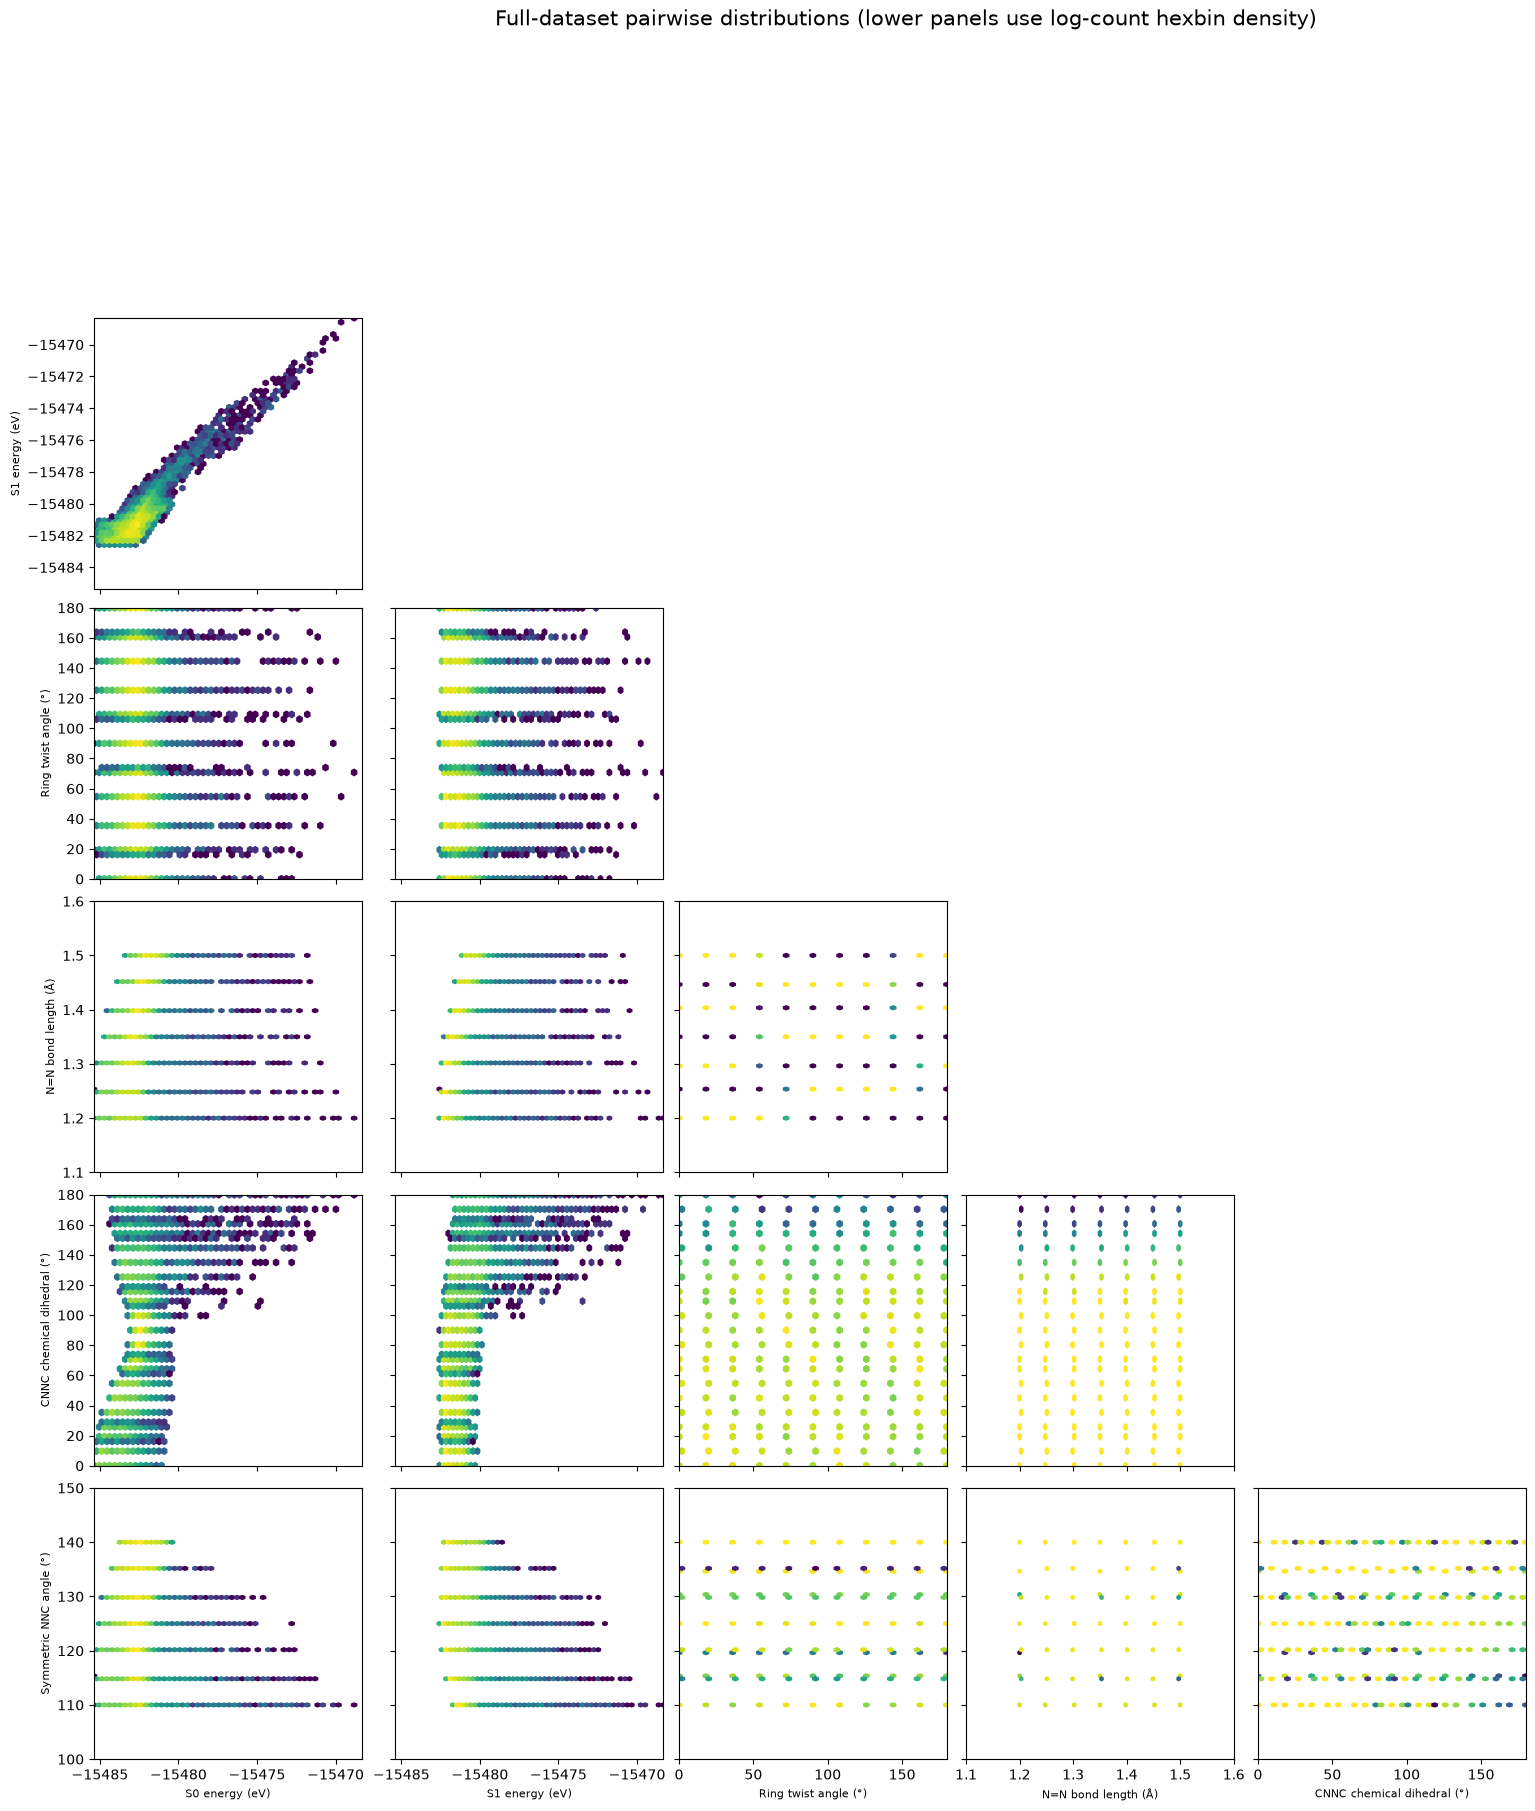

In [9]:
import pandas as pd

BOND_LENGTH_RANGE = (1.1, 1.6)  # Å, inclusive

analysis_data = pd.DataFrame({
    "S0 energy (eV)": energies_ev[:, 0],
    "S1 energy (eV)": energies_ev[:, 1],
    "Ring twist angle (°)": ring_twist_angle_deg,
    "N=N bond length (Å)": nn_bond_angstrom,
    "CNNC chemical dihedral (°)": dihedral_deg,
    "Symmetric NNC angle (°)": nnc_angle_deg,
})
analysis_data = analysis_data.loc[
    analysis_data["N=N bond length (Å)"].between(*BOND_LENGTH_RANGE)
].reset_index(drop=True)

if analysis_data.shape[1] != 6 or analysis_data.empty or not np.isfinite(analysis_data.to_numpy()).all():
    raise ValueError("Expected six finite analysis variables after bond-length filtering.")
if not analysis_data["N=N bond length (Å)"].between(*BOND_LENGTH_RANGE).all():
    raise ValueError("Analysis bond lengths must lie within the configured range.")
if not analysis_data["CNNC chemical dihedral (°)"].between(0.0, 180.0).all():
    raise ValueError("CNNC chemical dihedrals must lie in [0, 180].")

pearson_correlation = analysis_data.corr(method="pearson")
spearman_correlation = analysis_data.corr(method="spearman")
for correlation in (pearson_correlation, spearman_correlation):
    if not np.allclose(correlation, correlation.T) or not np.allclose(np.diag(correlation), 1.0):
        raise ValueError("Correlation matrix validation failed.")

display(analysis_data.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(17, 7), constrained_layout=True)
for axis, correlation, title in zip(
    axes, (pearson_correlation, spearman_correlation), ("Pearson correlation", "Spearman correlation")
):
    image = axis.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm")
    axis.set(xticks=range(len(correlation)), yticks=range(len(correlation)), title=title)
    axis.set_xticklabels(correlation.columns, rotation=45, ha="right")
    axis.set_yticklabels(correlation.index)
    for row in range(len(correlation)):
        for column in range(len(correlation)):
            value = correlation.iloc[row, column]
            axis.text(column, row, f"{value:.2f}", ha="center", va="center",
                      color="white" if abs(value) > 0.5 else "black", fontsize=8)
    fig.colorbar(image, ax=axis, label="Correlation coefficient")
plt.show()

# Lower-triangle hexbin matrix: each panel represents one pair of variables.
variable_names = analysis_data.columns.tolist()
variable_count = len(variable_names)
variable_limits = {
    "S0 energy (eV)": ENERGY_AXIS_LIMITS,
    "S1 energy (eV)": ENERGY_AXIS_LIMITS,
    "Ring twist angle (°)": (0, 180),
    "N=N bond length (Å)": (1.1, 1.6),
    "CNNC chemical dihedral (°)": (0, 180),
    "Symmetric NNC angle (°)": (100, 150),
}
fig, axes = plt.subplots(variable_count, variable_count, figsize=(18, 18), constrained_layout=True)
for row in range(variable_count):
    for column in range(variable_count):
        axis = axes[row, column]
        if row == column:
            axis.set_visible(False)
            continue
        elif row > column:
            axis.hexbin(analysis_data.iloc[:, column], analysis_data.iloc[:, row],
                        gridsize=50, mincnt=1, bins="log", cmap="viridis")
            axis.set_xlim(variable_limits[variable_names[column]])
            axis.set_ylim(variable_limits[variable_names[row]])
        else:
            axis.set_visible(False)
            continue
        if row == variable_count - 1:
            axis.set_xlabel(variable_names[column], fontsize=8)
        else:
            axis.tick_params(labelbottom=False)
        if column == 0:
            axis.set_ylabel(variable_names[row], fontsize=8)
        else:
            axis.tick_params(labelleft=False)
fig.suptitle("Full-dataset pairwise distributions (lower panels use log-count hexbin density)", fontsize=15)
plt.show()


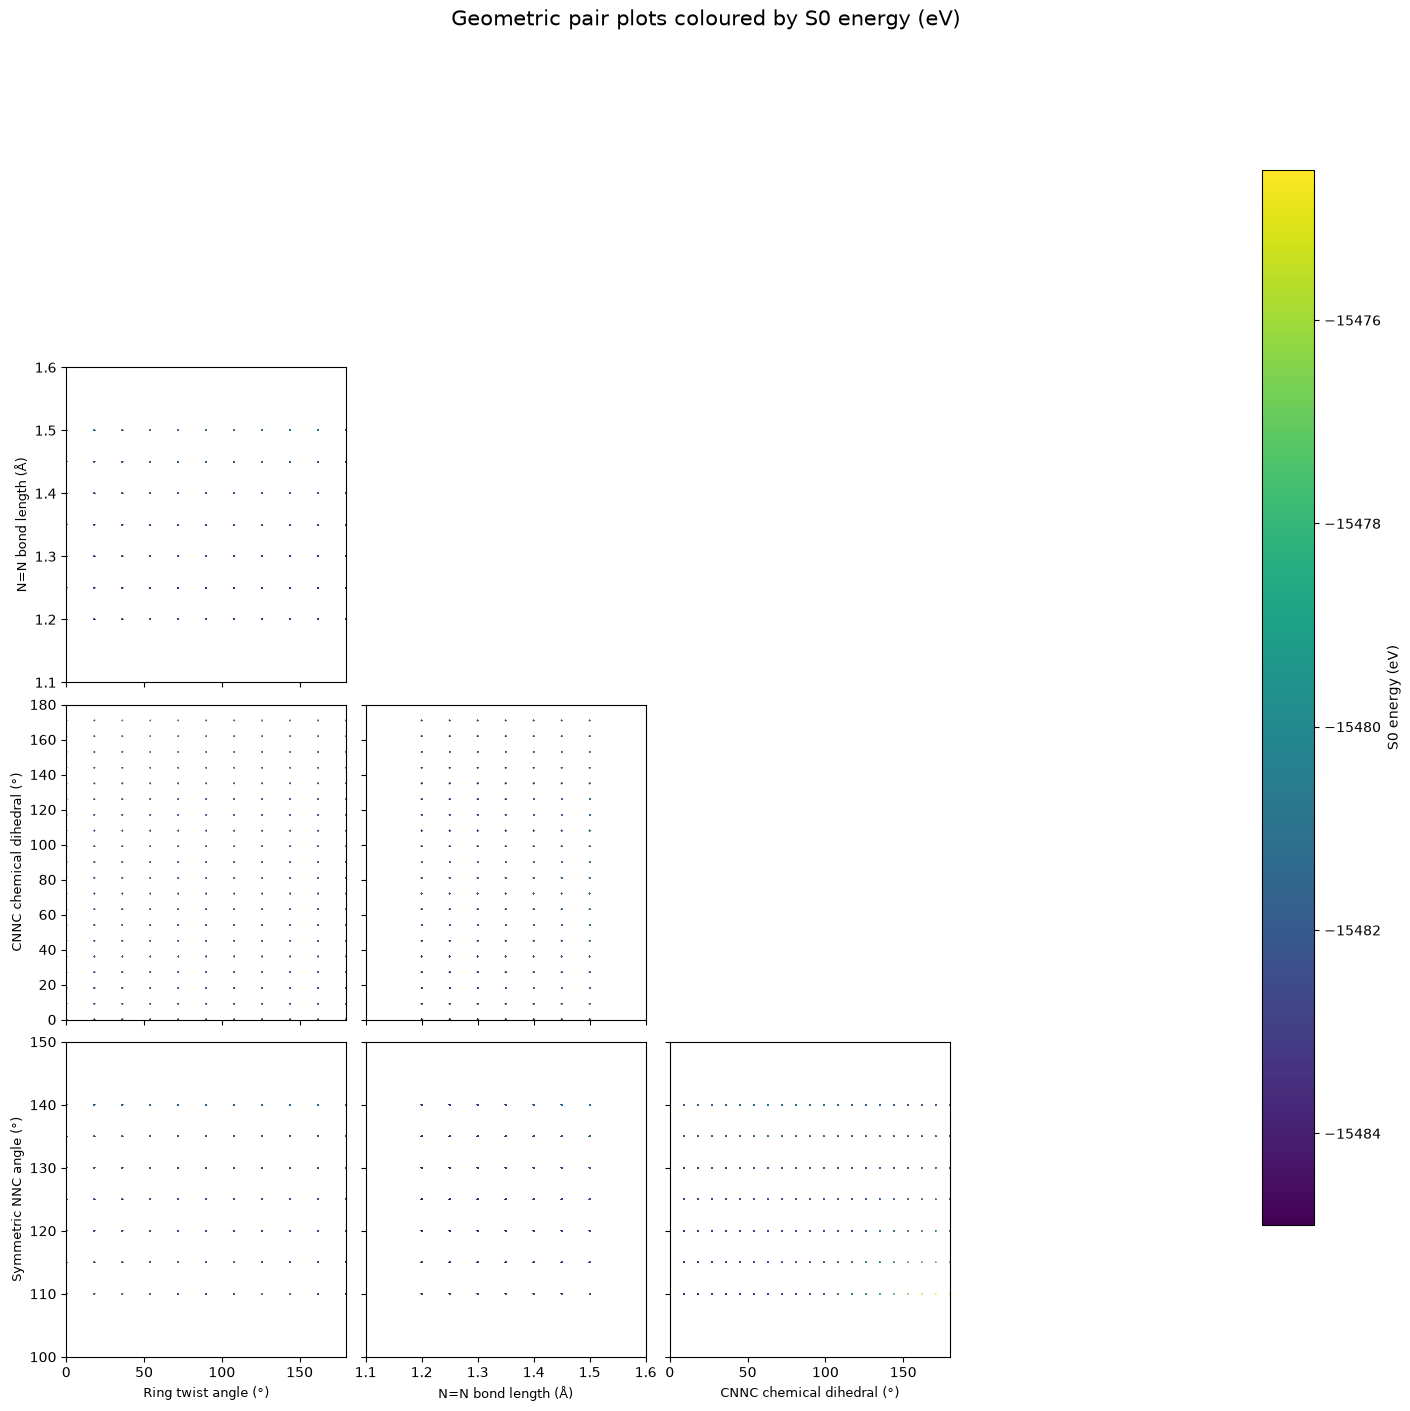

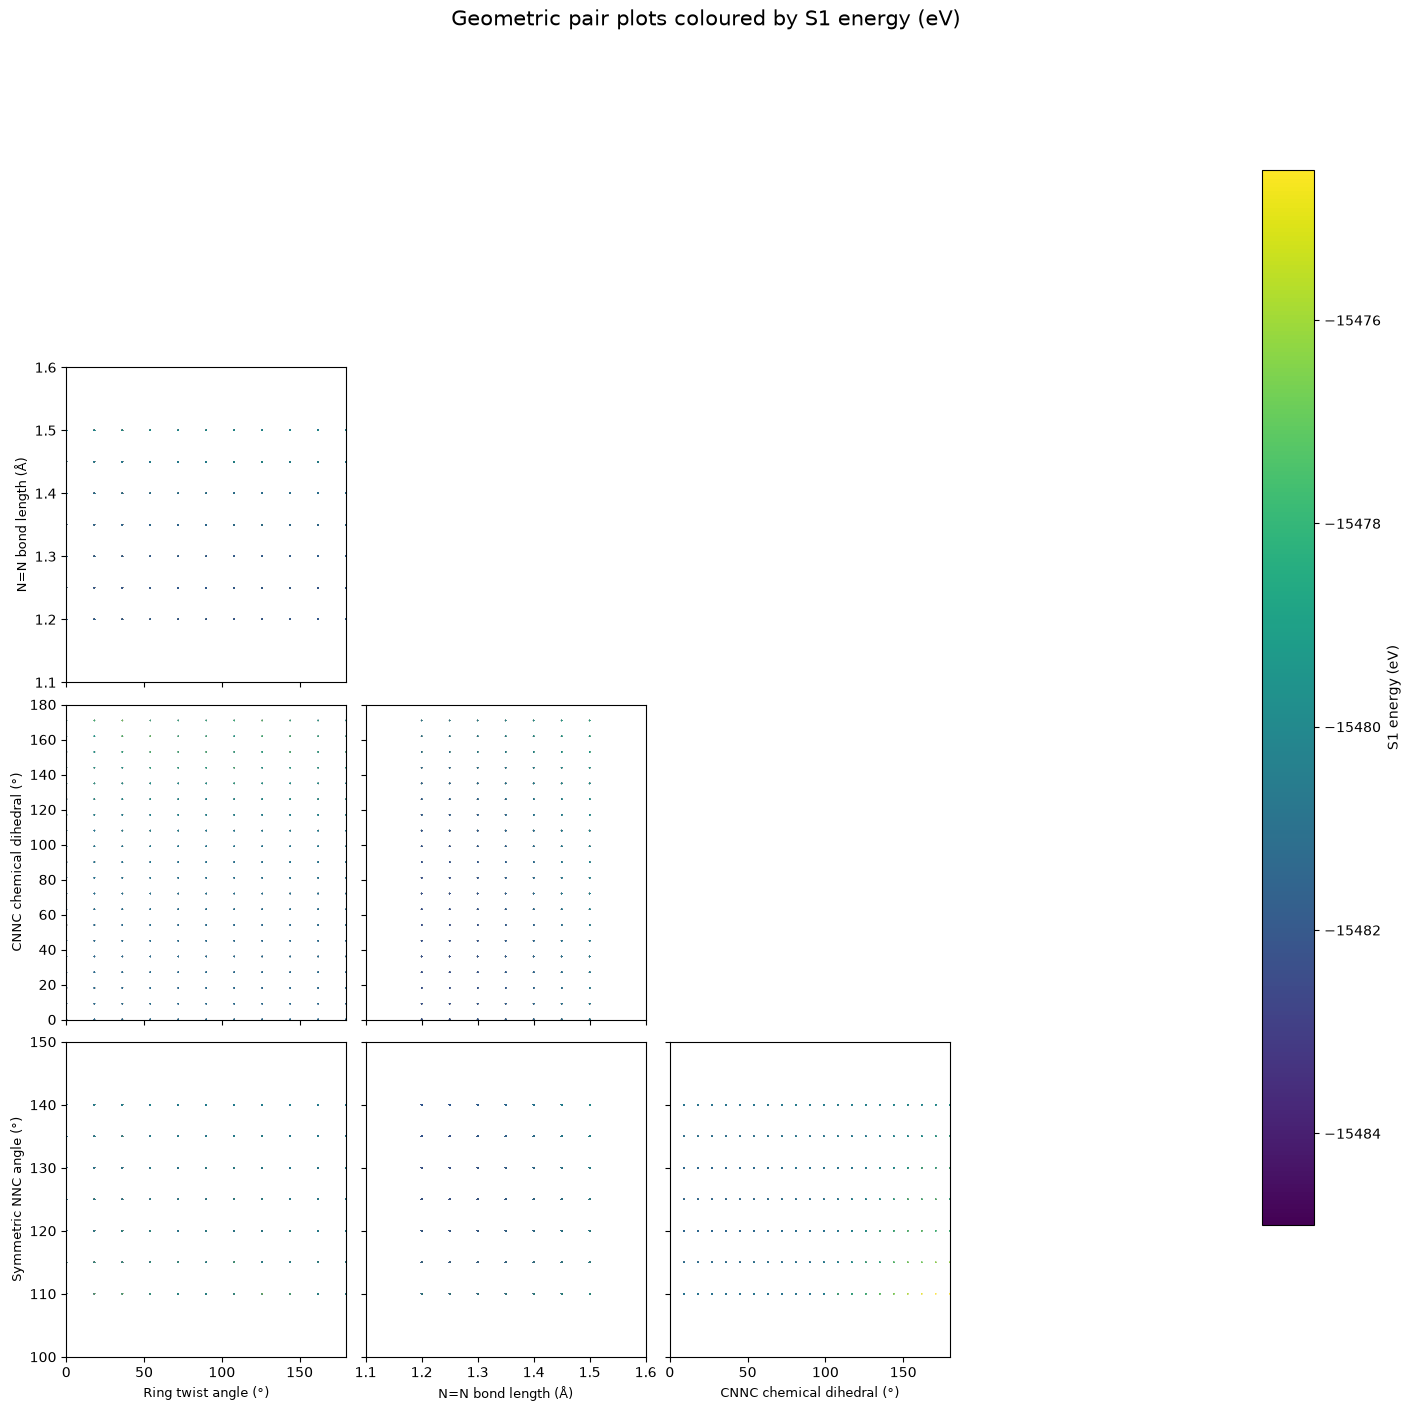

In [10]:
# Pairwise geometric relationships, coloured by the selected electronic-state energy.
GEOMETRY_VARIABLES = [
    "Ring twist angle (°)",
    "N=N bond length (Å)",
    "CNNC chemical dihedral (°)",
    "Symmetric NNC angle (°)",
]
ENERGY_COLOR_LIMITS = tuple(np.percentile(energies_ev, (1.0, 99.0)))
energy_color_norm = Normalize(vmin=ENERGY_COLOR_LIMITS[0], vmax=ENERGY_COLOR_LIMITS[1])

if not set(GEOMETRY_VARIABLES).issubset(analysis_data.columns):
    raise ValueError("Missing geometric variables for the energy-coloured pair plots.")

def plot_energy_coloured_triangle(energy_column):
    fig, axes = plt.subplots(
        len(GEOMETRY_VARIABLES), len(GEOMETRY_VARIABLES), figsize=(14, 14), constrained_layout=True
    )
    for row, y_variable in enumerate(GEOMETRY_VARIABLES):
        for column, x_variable in enumerate(GEOMETRY_VARIABLES):
            axis = axes[row, column]
            if row <= column:
                axis.set_visible(False)
                continue
            axis.scatter(
                analysis_data[x_variable], analysis_data[y_variable],
                c=analysis_data[energy_column], cmap="viridis", norm=energy_color_norm,
                s=1, alpha=0.15, linewidths=0, rasterized=True,
            )
            axis.set_xlim(variable_limits[x_variable])
            axis.set_ylim(variable_limits[y_variable])
            if row == len(GEOMETRY_VARIABLES) - 1:
                axis.set_xlabel(x_variable, fontsize=9)
            else:
                axis.tick_params(labelbottom=False)
            if column == 0:
                axis.set_ylabel(y_variable, fontsize=9)
            else:
                axis.tick_params(labelleft=False)
    colorbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=energy_color_norm, cmap="viridis"), ax=axes, shrink=0.8, pad=0.02
    )
    colorbar.set_label(energy_column)
    fig.suptitle(f"Geometric pair plots coloured by {energy_column}", fontsize=15)
    plt.show()

plot_energy_coloured_triangle("S0 energy (eV)")
plot_energy_coloured_triangle("S1 energy (eV)")
